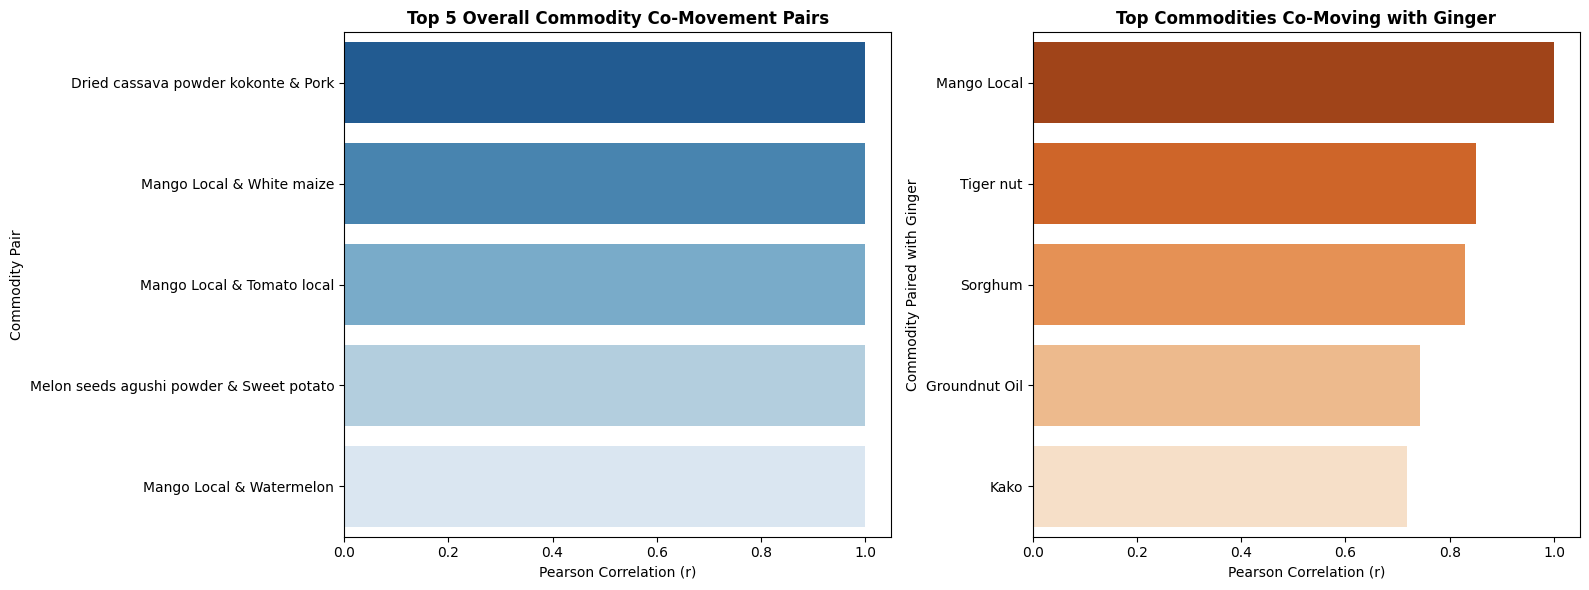

 TOP 5 OVERALL CO-MOVING PAIRS 
 Commodity_2                  Commodity_1  Correlation
        Pork Dried cassava powder kokonte          1.0
 White maize                  Mango Local          1.0
Tomato local                  Mango Local          1.0
Sweet potato    Melon seeds agushi powder          1.0
  Watermelon                  Mango Local          1.0

 TOP CO-MOVING PAIRS WITH GINGER
  Commodity_2 Commodity_1  Correlation
  Mango Local      Ginger     1.000000
    Tiger nut      Ginger     0.851004
      Sorghum      Ginger     0.829429
Groundnut Oil      Ginger     0.743576
         Kako      Ginger     0.717720


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load Cleaned Dataset
df = pd.read_csv('Commodity prices _(Cleaned).csv')

# 2. Format Date and Pivot Data
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
pivot_df = df.pivot_table(
    index=['Date', 'Market'], columns='Commodity', values='Price'
)

# 3. Calculate Correlation Matrix Across Commodities
commodity_corr = pivot_df.corr()

# 4. Extract Correlation Pairs (Fixing the Duplicate Column Name Error)
corr_pairs = (
    commodity_corr.rename_axis(index='Commodity_1', columns='Commodity_2')
    .unstack()
    .reset_index(name='Correlation')
)

# Remove self-correlations and duplicate reverse pairs
corr_pairs = corr_pairs[
    corr_pairs['Commodity_1'] < corr_pairs['Commodity_2']
].dropna()

# Sort by strongest positive correlation
top_pairs = corr_pairs.sort_values(by='Correlation', ascending=False)

# 5. Extract Pairs for Ginger Specifically
ginger_pairs = corr_pairs[
    (corr_pairs['Commodity_1'] == 'Ginger')
    | (corr_pairs['Commodity_2'] == 'Ginger')
].sort_values(by='Correlation', ascending=False)

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 5 Overall Pairs (Fixed Deprecation Warning)
top_5_plot = top_pairs.head(5).copy()
top_5_plot['Pair'] = (
    top_5_plot['Commodity_1'] + ' & ' + top_5_plot['Commodity_2']
)

sns.barplot(
    data=top_5_plot, 
    x='Correlation', 
    y='Pair', 
    hue='Pair', 
    ax=axes[0], 
    palette='Blues_r'
)
if axes[0].get_legend():
    axes[0].get_legend().remove()

axes[0].set_title(
    'Top 5 Overall Commodity Co-Movement Pairs', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Pearson Correlation (r)')
axes[0].set_ylabel('Commodity Pair')
axes[0].set_xlim(0, 1.05)

# Plot 2: Top Pairs Including Ginger (Fixed Deprecation Warning)
ginger_plot = ginger_pairs.head(5).copy()
ginger_plot['Other_Commodity'] = ginger_plot.apply(
    lambda r: r['Commodity_2']
    if r['Commodity_1'] == 'Ginger'
    else r['Commodity_1'],
    axis=1,
)

sns.barplot(
    data=ginger_plot,
    x='Correlation',
    y='Other_Commodity',
    hue='Other_Commodity',
    ax=axes[1],
    palette='Oranges_r',
)
if axes[1].get_legend():
    axes[1].get_legend().remove()

axes[1].set_title(
    'Top Commodities Co-Moving with Ginger', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Pearson Correlation (r)')
axes[1].set_ylabel('Commodity Paired with Ginger')
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

# 7. Print Numerical Summary
print(' TOP 5 OVERALL CO-MOVING PAIRS ')
print(top_pairs.head(5).to_string(index=False))

print('\n TOP CO-MOVING PAIRS WITH GINGER')
print(ginger_pairs.head(5).to_string(index=False))